# 01 - Pandas and NumPy Practice on Olist Dataset

This notebook started as pandas and NumPy practice, but the biggest learning was not only syntax or dataframe operations. The most important learning was applying business-rule validation checks on a real multi-table dataset.

In simple tutorial datasets, invalid rows are often dropped immediately. In this Olist dataset, that is risky because the data is relational: orders connect to customers, order items, sellers, products, payments, and reviews. Dropping rows from one table without understanding the relationship can create broken joins, missing foreign-key references, mismatched counts, and incorrect downstream analysis.

The better learning from this notebook is:

- Validate business rules table by table.
- Identify rows that violate expected rules.
- Understand whether the issue is truly bad data or valid business behavior.
- Avoid blindly dropping rows in relational data.
- Prefer flagging suspicious rows first, then deciding later whether to exclude them for a specific analysis or model.

This kind of business-rule validation and relational thinking is one of the most valuable parts of the project, because it is closer to real-world data work than most beginner tutorials.


Task 1: Load All CSV Files

Load:

customers\
orders\
order_items\
products\
sellers\
payments\
reviews

 Practice parameters:
 ```python
 encoding=
parse_dates=
dtype=
usecols=
nrows=
```


In [ ]:
import pandas as pd
import numpy as np
import sklearn.preprocessing
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifact"
ARTIFACT_DIR.mkdir(exist_ok=True)

customers = pd.read_csv(DATA_DIR / 'customers.csv', encoding='utf-8')
orders = pd.read_csv(
    DATA_DIR / 'orders.csv',
    encoding='utf-8',
    parse_dates=[
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
    ],
)
order_items = pd.read_csv(DATA_DIR / 'order_items.csv', encoding='utf-8', parse_dates=['shipping_limit_date'])
sellers = pd.read_csv(DATA_DIR / 'sellers.csv', encoding='utf-8')
products = pd.read_csv(DATA_DIR / 'products.csv', encoding='utf-8')
payments = pd.read_csv(DATA_DIR / 'order_payments.csv', encoding='utf-8')
reviews = pd.read_csv(
    DATA_DIR / 'order_reviews.csv',
    encoding='utf-8',
    parse_dates=['review_creation_date', 'review_answer_timestamp'],
)
geolocations = pd.read_csv(DATA_DIR / 'geolocation.csv', encoding='utf-8')


Task 2: Basic Inspection

For each dataframe:

.head()\
.tail()\
.sample()\
.shape\
.columns\
.info()\
.describe()\
.dtypes


In [ ]:
dfs = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "sellers": sellers,
    "products": products,
    "payments": payments,
    "reviews": reviews,
    "geolocations": geolocations,
}

for name,df in dfs.items():
    print(f"\n processing {name}")
    print(df.columns.to_list())

## Note: Column names are already in snake_case

In [ ]:

for name ,df in dfs.items():
    print(f"\n processing {name }")
    # print(f"\n first 5 rows of {name} ",df.head(5))
    # print(f"\n last 5 rows of {name } ",df.tail(5))
    # print(f"\n Random 5 rows of {name} ",df.sample(5))
    
    print("shape",df.shape)
    
    print("Objects columns",df.select_dtypes('object').columns.to_list())
    print("number columns",df.select_dtypes(include='number').columns.to_list())
    print("datetime columns ",df.select_dtypes(include='datetime').columns.to_list())
    print("bool",df.select_dtypes(include='bool').columns.to_list())
    # print("information about dataframe  ",df.info())
    
    # print("data frame column wise analysis ")
    # for col in df.columns.to_list():
      
    #     print(f"\n datatype of {col}:",df[col].dtypes)
    #     print(f"\n unique value in {col}:",df[col].nunique())
    #     print(f"\n most repeating value in {col}:",df[col].value_counts().head(5))
       
        

Task 3: Memory Usage

Check memory usage.
```python
df.memory_usage(deep=True)
```
Find:

largest columns\
object columns consuming most memory

Convert suitable columns to:

category


In [ ]:
for name, df in dfs.items():
    print(f"""
--- {name} ---""")
    
    # Memory usage per column
    mem = df.memory_usage(deep=True) # deep=True Give accurate memory for object columns
    print("""Top memory columns:
""", mem.sort_values(ascending=False).head(5))
    
    # Object columns with high memory
    obj_cols = df.select_dtypes('object')
    if not obj_cols.empty:
        obj_mem = obj_cols.memory_usage(deep=True)
        print("""Object columns memory:
""", obj_mem.sort_values(ascending=False))
    
    # Convert low-cardinality object columns to category
    for col in obj_cols.columns:
        nunique = df[col].nunique()
        ratio = nunique / len(df)
        if ratio < 0.05:  # adjust threshold as needed
            old_mem = df[col].memory_usage(deep=True)
            df[col] = df[col].astype('category')
            new_mem = df[col].memory_usage(deep=True)
            print(f"Converted {col} to category: {old_mem} -> {new_mem} bytes")
            
#  Logic:
# For each object column, compute nunique (number of distinct values).
# Calculate ratio = nunique / len(df) — percentage of unique values.
# If ratio < 5% (e.g., less than 5 unique per 100 rows), the column has low cardinality.
# Such columns are perfect for category dtype, which stores the mapping internally and can drastically reduce memory (e.g., from megabytes to kilobytes).
# We print before/after memory to see the saving.


# — Data Cleaning

Task 4: Standardize Column Names

Convert columns to:
```python 
snake_case
```

## Key Learning: Business Rule Validation in Relational Data

The business-rule checks in this notebook are not just cleaning steps. They are used to understand where the data violates expected business logic while preserving table relationships.

Because this dataset has many linked tables, directly deleting rows can create new problems:

- Orders may lose related payments, reviews, or items.
- Order items may reference products or sellers that no longer exist after filtering.
- Joins may silently lose rows and change business totals.
- Foreign-key style relationships may become inconsistent.

For that reason, suspicious rows should usually be flagged first. Dropping should happen only later, and only for a specific purpose such as EDA, modeling, or a clearly defined business rule.


In [ ]:
#### Already in snake case 

## script for that purpose 

###------------------------------------------------------------------------------------------

## Method 1

# for name ,df in dfs.items():
#     print(f"\n --------------{name}-------------------")
#     for col in df.columns.to_list():
#         print("before: ",col)
#         col.strip().lower().replace(" ","_").replace("-","_")
#         print("after ",col)


## Method 2:

# for name ,df in dfs.items():
#     print("before ",df.columns.to_list())
#     df.columns = (
#         df.columns
#         .str.strip()
#         .str.lower()
#         .str.replace(" ", "_")
#         .str.replace("-", "_")
#     )
#     print(f"fixed columns in  {name}",df.columns.to_list())

## Advance Methods using Regex 

Task 5: Missing Values Analysis

Find: 
```python
isnull().sum()
```
Questions:

Which columns have highest missing values?\
Which columns should be dropped?\
Which should be imputed?

```python
isnull().mean()*100
```
Questions:

Which columns have highest missing values?\
Which columns should be dropped?\
Which should be imputed?



In [ ]:
## Missing Value Analysis 

for name ,df in dfs.items():
    print(f"---------------------{name}-------------------------------------------")
    for col in df.columns.to_list():
        print(f"Missing Value in {col}",df[col].isnull().sum())
        
## Note  :

## No missing values in  any column of customers ,sellers,orders,order_items,payments,geolocation
## Missing values Present in products :
# Missing Value in product_category_name 610
# Missing Value in product_name_lenght 610
# Missing Value in product_description_lenght 610
# Missing Value in product_photos_qty 610
# Missing Value in product_weight_g 2
# Missing Value in product_length_cm 2
# Missing Value in product_height_cm 2
# Missing Value in product_width_cm 2

## Missing values present in reviews
# Missing Value in review_comment_title 87656
# Missing Value in review_comment_message 58247

Task 6: Duplicate Analysis

Check duplicates.
```python 
duplicated()
drop_duplicates()
```
Find duplicate order IDs/customer IDs.


In [ ]:
## Duplicate Rows Check
for name ,df in dfs.items():
    print(f"----------------------------{name}---------------------------------------")
    print(f"Duplicate rows :", df.duplicated().sum())

Task 7: Data Type Corrections
Convert:

dates → datetime\
IDs → string/category\
prices → float

Practice:

```python
astype()
pd.to_datetime()
pd.to_numeric()
```

In [ ]:
##1 converting to Date-time for datetime columns 

# I missed order_purchase_timestamp intentionally not parsing as datetime while loading , so fix that

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

##2 Fixing spelling Mistakes in column name 

# In products table  some columns has incorrect spelling name 
print(products.columns.to_list())

# Product_name_lenght -Incorrect spelling  (basically length should be length  )

products.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"
}, inplace=True)

print("After fixing: ",products.columns.to_list())


In [ ]:

##3 DTYPE CORRECTION - OLIST ( This step is optional but it is good to do for memory optimization and also for better understanding of data )

## i have Just changed otherwise this step can be skipped 

# ---------- CUSTOMERS ----------

customers = customers.astype({
    "customer_id": "string",
    "customer_unique_id": "string",
    "customer_city": "string",
    "customer_state": "string",
    "customer_zip_code_prefix": "string"
})


# ---------- SELLERS ----------

sellers = sellers.astype({
    "seller_id": "string",
    "seller_city": "string",
    "seller_state": "string",
    "seller_zip_code_prefix": "string"
})


# ---------- PRODUCTS ----------

products = products.astype({
    "product_id": "string",
    "product_category_name": "string",

    "product_name_length": "Int32",
    "product_description_length": "Int32",
    "product_photos_qty": "Int16",

    "product_weight_g": "float32",
    "product_length_cm": "float32",
    "product_height_cm": "float32",
    "product_width_cm": "float32"
})


# ---------- ORDERS ----------

orders = orders.astype({
    "order_id": "string",
    "customer_id": "string",
    "order_status": "string"
})


# ---------- ORDER ITEMS ----------

order_items = order_items.astype({
    "order_id": "string",
    "product_id": "string",
    "seller_id": "string",

    "order_item_id": "Int16",

    "price": "float32",
    "freight_value": "float32"
})




# ---------- PAYMENTS ----------

payments = payments.astype({
    "order_id": "string",
    "payment_type": "string",

    "payment_sequential": "Int16",
    "payment_installments": "Int16",

    "payment_value": "float32"
})


# ---------- REVIEWS ----------

reviews = reviews.astype({
    "review_id": "string",
    "order_id": "string",

    "review_comment_title": "string",
    "review_comment_message": "string",

    "review_score": "Int8"
})




# ---------- GEOLOCATIONS ----------

geolocations = geolocations.astype({
    "geolocation_zip_code_prefix": "string",
    "geolocation_city": "string",
    "geolocation_state": "string",

    "geolocation_lat": "float32",
    "geolocation_lng": "float32"
})


# ==============================
# UPDATE DFS DICTIONARY
# ==============================

dfs = {
    "customers": customers,
    "sellers": sellers,
    "products": products,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "geolocations": geolocations
}


# ==============================
# CHECK FINAL DTYPES
# ==============================

for name, df in dfs.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)

## **Business Rule Validation**

In [ ]:
##4 Business Rules validation 

# ==============================
# BUSINESS RULE CHECKS - OLIST
# ==============================

## Orders Validation 
order_issues = {}

# 1. Orders: delivery cannot happen before purchase
order_issues["delivery_before_purchase"] = orders[
    orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]
]

# 2. Orders: carrier delivery cannot happen before purchase
order_issues["carrier_before_purchase"] = orders[
    orders["order_delivered_carrier_date"] < orders["order_purchase_timestamp"]
]

# 3. Orders: customer delivery cannot happen before carrier delivery
order_issues["customer_before_carrier"] = orders[
    orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]
]

# 4. Orders: approved date cannot be before purchase date
order_issues["approval_before_purchase"] = orders[
    orders["order_approved_at"] < orders["order_purchase_timestamp"]
]

# 5. Delivered orders should have delivered customer date
order_issues["delivered_without_delivery_date"] = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
]

# 6. Non-delivered orders having delivered date
order_issues["not_delivered_but_has_delivery_date"] = orders[
    (orders["order_status"] != "delivered") &
    (orders["order_delivered_customer_date"].notna())
]

# 7. Cancelled/unavailable orders should often have missing delivery date
order_issues["cancelled_or_unavailable_with_delivery"] = orders[
    (orders["order_status"].isin(["canceled", "unavailable"])) &
    (orders["order_delivered_customer_date"].notna())
]

for name, data in order_issues.items():
    print(name, ":", data.shape[0])
    
 

In [ ]:
## PRODUCT Business Rule 

product_issues = {}

# negative or zero dimensions
product_issues["invalid_weight"] = products[
    products["product_weight_g"] <= 0
]

product_issues["invalid_length"] = products[
    products["product_length_cm"] <= 0
]

product_issues["invalid_height"] = products[
    products["product_height_cm"] <= 0
]

product_issues["invalid_width"] = products[
    products["product_width_cm"] <= 0
]

# negative text/photo values

product_issues["negative_name_length"] = products[
    products["product_name_length"] < 0
]

product_issues["negative_description_length"] = products[
    products["product_description_length"] < 0
]

product_issues["negative_photos_qty"] = products[
    products["product_photos_qty"] < 0
]

for name, data in product_issues.items():
    print(name, ":", data.shape[0])

In [ ]:
## PAYMENT Business Rule

payment_issues = {}

payment_issues["invalid_payment_value"] = payments[
    payments["payment_value"] <= 0
]

payment_issues["invalid_installments"] = payments[
    payments["payment_installments"] < 0
]

payment_issues["invalid_payment_sequential"] = payments[
    payments["payment_sequential"] <= 0
]

for name, data in payment_issues.items():
    print(name, ":", data.shape[0])

In [ ]:
## ORDER_ITEMS BUSINESS RULE

order_item_issues = {}

order_item_issues["invalid_price"] = order_items[
    order_items["price"] <= 0
]

order_item_issues["invalid_freight"] = order_items[
    order_items["freight_value"] < 0
]

order_item_issues["invalid_order_item_id"] = order_items[
    order_items["order_item_id"] <= 0
]

for name, data in order_item_issues.items():
    print(name, ":", data.shape[0])

In [ ]:
## REVIEWS BUSINESS RULES

review_issues = {}

review_issues["invalid_review_score"] = reviews[
    ~reviews["review_score"].between(1, 5)
]

review_issues["answer_before_creation"] = reviews[
    reviews["review_answer_timestamp"] < reviews["review_creation_date"]
]

for name, data in review_issues.items():
    print(name, ":", data.shape[0])

In [ ]:
## Geolocation Business Rule

geo_issues = {}

geo_issues["invalid_latitude"] = geolocations[
    ~geolocations["geolocation_lat"].between(-34, 6)
]

geo_issues["invalid_longitude"] = geolocations[
    ~geolocations["geolocation_lng"].between(-74, -34)
]

for name, data in geo_issues.items():
    print(name, ":", data.shape[0])
    


In [ ]:
## All issue Summary

all_issues = {
    **order_issues,
    **product_issues,
    **payment_issues,
    **order_item_issues,
    **review_issues,
    **geo_issues
}

## No of rows affected by each issue count

issue_summary = pd.DataFrame({
    "issue": list(all_issues.keys()),
    "rows_affected": [df.shape[0] for df in all_issues.values()]
}).sort_values("rows_affected", ascending=False)

issue_summary

In [ ]:
##  Olist dataset is Relational:

# orders
#    ↓
# order_items
#    ↓
# payments
#    ↓
# reviews

# Why we can't drop Business Rule Violatiing rows in each table:

# joins may fail{ Broken Join Problem }
# foreign key relations may break{}
# customer/order counts change{ }
# revenue changes{ }
# delivery metrics become biased{ }

# ==============================
# SOLUTION Business Rule Flags
# ==============================

orders["flag_carrier_before_purchase"] = (
    orders["order_delivered_carrier_date"] < orders["order_purchase_timestamp"]
)

orders["flag_customer_before_carrier"] = (
    orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]
)

orders["flag_delivered_without_delivery_date"] = (
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
)

orders["flag_status_delivery_mismatch"] = (
    (orders["order_status"] != "delivered") &
    (orders["order_delivered_customer_date"].notna())
)

payments["flag_invalid_payment_value"] = payments["payment_value"] <= 0

products["flag_invalid_weight"] = products["product_weight_g"] <= 0
products.loc[products["product_weight_g"] <= 0, "product_weight_g"] = np.nan

geolocations["flag_invalid_latitude"] = ~geolocations["geolocation_lat"].between(-34, 6)
geolocations["flag_invalid_longitude"] = ~geolocations["geolocation_lng"].between(-74, -34)

# analysis-specific clean views
payments_clean = payments[payments["payment_value"] > 0].copy()

geolocations_clean = geolocations[
    geolocations["geolocation_lat"].between(-34, 6) &
    geolocations["geolocation_lng"].between(-74, -34)
].copy()

SyntaxError: invalid character '↓' (U+2193) (3777307179.py, line 4)

#  — **NumPy Practice**

NumPy Array Creation

Create arrays from:

prices\
freight values\
payment values\
review scores\
product name lengths\
product description lengths

example:
```python 
prices = order_items_df['price'].to_numpy()
```

practice :
```python 
np.array()
np.arange()
np.linspace()
np.zeros()
np.ones()
np.random.randint()
```


In [ ]:
# prices , freight_values ,payment_values


#PRICE 
price=order_items['price'].to_numpy(dtype='float') # we have specified dtype='float'

# But by default it convert into 'float' 

print("prices: ", price.dtype)
print("prices: ",price[:5]) # first 5 vales of prices from index 0,1,2,3,4 excluding index 5

# FREIGHT_VALUES 
freight_values=order_items['freight_value'].to_numpy()

print("freight values: ",freight_values.dtype)
print("freight values: " ,freight_values[:5])

# PAYMENT_VALUES

payment_values=payments['payment_value'].to_numpy()
print("payment values: ",payment_values.dtype)
print("payment values: " ,payment_values[:5])




# REVIEW_SCORES

review_scores=reviews['review_score'].to_numpy()
print("review_scores: " ,review_scores[:5])
print("review scores: ",review_scores.dtype)


# PRODUCT_NAME LENGTHS
product_name_lengths=products['product_name_length'].to_numpy()
print("product_name_lengths: ", product_name_lengths[:5])
print("product_name_lengths dtype: ", product_name_lengths.dtype)
print("freight values: " ,freight_values[:5])

# for col in products.columns.to_list():
#     print(f"column {col} ",products[col].dtype)

# PRODUCT DESCRIPTION LENGTH
product_description_lengths=products['product_description_length'].to_numpy()
print("product_description_lengths: ", product_description_lengths[:5])
print("product_description_lengths dtype: ", product_description_lengths.dtype)


In [ ]:

# ========== PRACTICE: NumPy Array Creation Methods ==========


# np.array() - create array from list

arr_from_list = np.array([1, 2, 3, 4, 5])
print("\nnp.array() from list:", arr_from_list)

# np.arange() - create array with range

arr_arange = np.arange(0, 10, 2)
print("np.arange(0, 10, 2):", arr_arange)

# np.linspace() - create array with evenly spaced numbers

arr_linspace = np.linspace(0, 1, 5)
print("np.linspace(0, 1, 5):", arr_linspace)

# np.zeros() - create array of zeros

arr_zeros = np.zeros(5)
print("np.zeros(5):", arr_zeros)

# np.ones() - create array of ones

identity_matrix = np.ones((3, 3))
print("np.ones((3,3)):\n", identity_matrix)

# np.random.randint() - create array with random integers

arr_random = np.random.randint(1, 100, 5)
print("np.random.randint(1, 100, 5):", arr_random)

# Inspect Arrays

For each array:

Find:

shape\
ndim\
dtype\
size

Example:
```python
prices.shape
prices.dtype
```


In [ ]:
## Inspection 

print("price shape : ",price.shape)
print("price: ",price.dtype)
print("price dimension",price.ndim)
print("price array size ",price.size)
print("elements size in price array: ",price.itemsize)
print("----------------------------------------------------------------")
print("idenity matrix dimenion ",identity_matrix.ndim)
print("identity matrix shape ",identity_matrix.shape)

Convert arrays into:

float\
int\
string

Questions:

What happens when float converts to int?\
What happens if null values exist?

In [ ]:
price=price.astype('int')
print(price.dtype)

product_name_lengths = np.array(
    products['product_name_length']
    .fillna(0)
)

## Pandas Missing value object 

product_name_lengths = (
    product_name_lengths.astype(float)
)
print("product_name_lengths datatype after : ",product_name_lengths.dtype)
print(product_description_lengths)

# Question  1: Decimals are truncated after converting float into integer , not rounded,if converted carelessly or 
# while creating numpy if datatype is defined wrongly decimal precision may lost 

# Queestion 2:

# This is Important 

# Important Information :Pandas considers the following as missing values by default:

# | Value in CSV           | Considered Missing? |
# | ---------------------- | ------------------- |
# | empty cell             | Yes                 |
# | `NaN`                  | Yes                 |
# | `N/A`                  | Yes                 |
# | `NULL`                 | Yes                 |
# | `None`                 | Yes                 |
# | blank spaces sometimes | Depends             |

# Not considered missing :By default pandas does not consider the following as missing values:

# 'unknown'
# '?'
# '-'
# 'missing_value'

## These stays string unless we specifically define :

## na_values=['unknown', '?']

## Explicitly defining missing values while loading data:

# example
# pd.read_csv(
#     'data.csv',
#     na_values=['unknown', '?']
# )

# coming back to our question 

# In our dataset product ,product_name_lengths contains missing values and data type of column is integer
# since we have change manually np.nan ->type(np.nan) is float so for column whose datatype is int 
# np.nan is not compatible for missing value representation so pandas represent using pd.NA 
# but that create problem when creating Numpy array

# Case 1 — Convert to Float
# arr.astype(float)
# Usually works IF missing values are compatible.
# Missing becomes:np.nan

# Case 2 — Convert to Int

# arr.astype(int)
# Usually FAILS.

# Because normal NumPy integers cannot store missing values.

# You may get errors like:



# Synthetic Ecommerce Data

Generate random:

quantities sold
review scores
delivery days
discount percentages
seller ratings

In [ ]:
# SYNTHETIC DATA GENERATION 

qunatities_sold_gen=np.random.randint(1,100,5)
print("randomly generated 5 values for qunatities_sold in the range 1 to 100: ",qunatities_sold)
review_score_gen=np.random.randint(1,5,10)
print("reviews score manually generated : ",review_score_gen)





#  Matrix Creation

Create:

5×5 zeros matrix\
3×4 ones matrix\
4×4 identity matrix

In [ ]:
## MATRIX CREATION


## General  Matrix Creation 
### method 1
matrix_1 =np.array([[1,2,3],[4,5,6],[7,8,9]])
print("method1: creating Matrix")
print(matrix_1)
## Method 2 Using range and reshape 
matrix_2=np.arange(1,13).reshape(3,4)
print("Method2 creating matrix using arange and reshape ")
print(matrix_2)
## Random Matrix 
print("Random matrix of anyshape ")
matrix_3=np.random.randint(1,100,(4,5))
print(matrix_3)
## diagonal Matrix Creation 
print("Diagonal matrix")
matrix1=np.diag([1,2,3,4,5])
print(matrix1)

## zero matrix Creation 
matrix_zero_1=np.zeros(5)
print("zero Matrix example 1 D ")
print(matrix_zero_1)
matrix_zero_2=np.zeros((3,4))
print("zero matrix example 2 ")
print(matrix_zero_2)

## identity Matrix 
matrix_identity_1=np.eye(5)
print("identity matrix ")
print(matrix_identity_1)

matrix_identity_2=np.identity(4)
print(matrix_identity_2)


# Basic Slicing

From prices array:

Extract:

first 10 values\
last 20 values\
middle 50 values\
every 5th value



In [ ]:
print("first 10 values of prices : ",price[:10])
print("last 20 values of price",price[-20:])

mid=len(price)//2
print("middle 50 values ",price[-mid-25:mid+25])

print("every 5th values ",price[::5])

# Simple Conditional Filtering

prices > 500\
freight > 100\
payment values < 50\
review scores == 5


In [ ]:
print("prices greater than 500 ",price[price>500])
print("freight greater than 100: ",len(freight_values[freight_values>100]))
print("payment Values less than 50: ",len(payment_values[payment_values<50]))
print("reviews score ==5: ",len(review_scores[review_scores==5]))

# aggregates function  

average product price\
maximum payment value\
minimum freight charge\
total revenue\
total freight collected


In [ ]:
# avg_product_price=sum(price)/len(price)
# print("avarge product prize",avg_product_price)
# print("maximum payment value: ",max(payment_values))
# print("Minimum freight charge : ",min(freight_values))
# print("total revenue ",sum(price)-sum(freight_values))
# print("total freight collected ",sum(freight_values))

## Numpy style 
print("avarge product prize",np.mean(price))
print("maximum payment value: ",np.max(payment_values))
print("Minimum freight charge : ",np.min(freight_values))
print("total revenue ",np.sum(price))
print("total freight collected ",np.sum(freight_values))


# — Percentiles

Find:

25th percentile\
50th percentile\
75th percentile\
90th percentile

In [ ]:
print("25th percentile ",np.percentile(price,25))
print("50th percentile ",np.percentile(price ,50))
print("75th percentile ",np.percentile(price,75))
print("90th percentile ",np.percentile(price,90))

# Vectorized Operations 


Discount Simulation

## Assume 10% discount on all products.

Create new discounted prices.


 ## Add 18% GST to prices.

## Increase freight by:

5%\
10%\
20%\

Compare results.

In [ ]:
## Vectorized Operations 

## Discount 
discounted_price=price*(1-0.1)
print("original price ",price)
print("Discounted price ",discounted_price)

## GST 
final_price =price *(1+0.18)
print("final price ",final_price)

## freight price increment 
print("original freight price ",freight_values)
print("freight price incremet by 5 percent ",freight_values*(1+0.05))
print("freight price incremet by 10 percent ",freight_values*(1+0.1))
print("freight price incremet by 20 percent ",freight_values*(1+0.2))

# Reshape Arrays

Convert first 100 prices into:

10×10 matrix\
20×5 matrix

In [ ]:
print("10 by 10 price matrix of first 100 price values ")
print(price[:100].reshape(10,10))
matrix_1_price=price[:100].reshape(10,10)
print("20 by 5 price matrix ")
print(price[:100].reshape(20,5))
matrix_2_price=price[:100].reshape(20,5)

Flatten Matrix

Practice:
```python
flatten()
ravel()
```


In [ ]:
flatten_matrix=matrix_1_price.flatten()
print(flatten_matrix)
print(flatten_matrix.ndim)
print(flatten_matrix.shape)

# print(matrix_1_price.ravel())
# print(matrix_1_price.ravel().shape)

Stacking

Combine:

prices
freight values

vertical stacking 
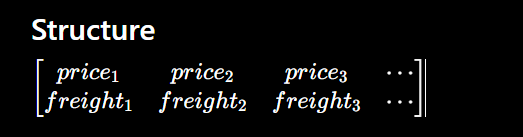

Horizontal stacking 

All prices values followed by all freight values 

column_stack(Best Most used)


In [ ]:

## Verticcal stacking 
stacked_vertical=np.vstack((price,freight_values))
print("vertically stacked ",stacked_vertical)
print("shape ",stacked_vertical.shape)
## Horizantally stacked 
stacked_horizontal=np.hstack((price ,freight_values))
print("horizantally stacked")

## Column stacked 
column_stacked=np.column_stack((price,freight_values))
print("column stacked ")
print(column_stacked)

Normalize Prices

Apply Min-Max Scaling:

x(norm)=x−x(max)/x(max)−x(min)
	​

	​


In [ ]:
# Normalization 
price_max=np.max(price)
price_min=np.min(price)
price_normalized=(price-price_max)/(price_max-price_min)
print(price)
print(price_normalized)

Standardization

Apply Z-score standardization:

In [ ]:
# Z- Score values 
price_mean=np.mean(price)

price_std_deviation=np.std(price)

price_z_score=(price-price_mean)/price_std_deviation
print(price_z_score)

# Outliers using Z -score 
outliers=price[np.abs(price_z_score)>3]
print(outliers)

Outlier Detection

Detect outliers using IQR method:

IQR=Q3−Q1

Find:

lower bound\
upper bound\
outlier prices

In [ ]:
## Outliers using IQR Method

Q1=np.percentile(price,25)
Q3=np.percentile(price,75)
IQR=Q3-Q1
lower_limit=Q1-15.*IQR
uppper_limit=Q3+1.5*IQR
outlier=price[(price <lower_limit) | (price>uppper_limit)]
print(len(outlier))
print(len(price))

Task 10: Conditional Filtering using NumPy

Use:
```python
np.where()
np.select()
```
create 
```python
high_value_order
```
Conditions:

payment > 500 → High\
payment 200–500 → Medium\
else Low



In [ ]:
high_value_order = np.where(
    payment_values > 500,
    "High",
    np.where(
        (payment_values >= 200) & (payment_values <= 500),
        "Medium",
        "Low"
    )
)

print(high_value_order)

#  **— Pandas Filtering & Indexing**

Task 12: Filtering Practice

Find:

Delivered orders\
Cancelled orders\
Orders above average payment\
Orders from specific states\
Orders after 2018

use:
``python 
loc
iloc
query
boolean masking
```


In [ ]:
## Pandas Filtering and indexing

## delivered and cancelled orders 
delivered_orders=orders[orders['order_status']=='delivered']
cancelled_orders=orders[orders['order_status']=='canceled']
print("delivered orders ")
print(delivered_orders.head(5))
print("cancelled orders")
print(cancelled_orders.head(5))



In [ ]:

orders_payments=orders.merge(payments ,on='order_id',how='inner')
print("Merged orders and payments tables ")
orders_payments
avg_order_value=np.mean(payment_values) ## Average calculate using numpy array 
avg_order_payment=payments['payment_value'].mean() ## Average calculate using pandas series
## Above averge price  orders 
above_avg_orders=orders_payments[orders_payments['payment_value']>avg_order_payment]
print("above average orders")
print(above_avg_orders)

In [ ]:
orders_customers=orders.merge(customers ,on='customer_id',how='inner',)
# print(customers['customer_state'].unique())

## Orders from specific states 
filtered_orders=orders_customers[orders_customers['customer_state'].isin(['SP','RJ'])]
print(filtered_orders)

In [ ]:
## orders after specific year

print(orders[orders['order_purchase_timestamp']>='2018-01-01'][['order_id','order_purchase_timestamp']])

# **— GroupBy & Aggregation**

Task 13: GroupBy Basics

Find:

Average payment by state\
Total revenue by seller\
Orders per customer\
Average freight by category

practice 
```python
groupby()
agg()
```
```python
mean
sum
count
nunique
max
min
```


In [ ]:
## Average payment By state 

orders_customers_payments=orders_customers.merge(payments,on='order_id',how='inner')
orders_customers_payments.groupby('customer_state')['payment_value'].mean()

In [ ]:
## Total revenue By seller 

# for name ,df in dfs.items():
#     print(f"-----{name}------------")
#     print(df.columns)

order_items__sellers=order_items.merge(sellers,on='seller_id',how='inner')
order_items__sellers.groupby(['seller_id','seller_city','seller_state'])['price'].sum()

In [ ]:
## Orders per Customers 

## customer_unique_id -represent real customer not customer_id
customer_total_orders=orders_customers.groupby('customer_unique_id')['order_id'].count().reset_index()
customer_total_orders.columns=['customer_id','total_orders']
print(customer_total_orders.sort_values(by='total_orders',ascending=False))

In [ ]:
## Average freight by category 

# for name ,df in dfs.items():
#     print(f"-----{name}------------")
#     print(df.columns)

order_items_products=order_items.merge(products,on='product_id',how='inner')

Average_freight_by_category=order_items_products.groupby('product_category_name')['freight_value'].mean().reset_index()
Average_freight_by_category.columns=[
    'product_category_name','average_freight_value'
]
Average_freight_by_category

Task 14: Multi-level Aggregation

Example:
```python
.groupby(["customer_state","order_status"])
```
Find:


total orders\
average payment\
unique customers



In [ ]:
## Total orders by states and status 

total_orders_by_state_and_status=orders_customers.groupby(['customer_state','order_status'])['order_id'].count().reset_index()

total_orders_by_state_and_status.columns=[
    'customer_state','order_status','count'
]
total_orders_by_state_and_status

# average order payment by state and status 
average_orders_by_state_and_status=orders_customers_payments.groupby(
    ['customer_state','order_status']
    )['payment_value'].mean().reset_index()

average_orders_by_state_and_status.columns=[
    'customer_state','order_status','average_payment'
]
print(average_orders_by_state_and_status)
## Unique customers 
print("unique customers : ",orders_customers['customer_unique_id'].nunique())

 Named Aggregation



In [ ]:
## Name Aggregation Example 

summary=orders_customers.groupby('customer_state').agg(
    total_orders=('order_id','count'),
    unique_customers=('customer_unique_id','nunique')
).reset_index()
summary

Task 17: Identify Merge Problems

Check:
```python
isnull()
```
after merging

Find unmatched records.


In [ ]:
## Identifying Missing values after Merging
print(orders_customers.isnull().sum())
print("----------------------------------------------")
print(orders_payments.isnull().sum())


# **— DateTime Operations**

Extract:
year\
month\
day\
weekday\
quarter

Create:
delivery_time\
approval_time

 using datetime subtraction.



In [ ]:
date_time_columns=[
    
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
    
]

for col in date_time_columns:
    print("Before datatype",orders[col].dtype)
    orders[col]=pd.to_datetime(orders[col])
    print("after datatype ",orders[col].dtype)
 
orders['year']=orders['order_purchase_timestamp'].dt.year
orders['month']=orders['order_purchase_timestamp'].dt.month
orders['day']=orders['order_purchase_timestamp'].dt.day
print(orders.iloc[:,-3:])
## iloc position wise filtering 
## loc name wise filtering
print("------------------------")
print(orders.loc[:,'year':'day'])

Task 19: Time-based Analysis

Find:

Monthly revenue\
Quarterly orders\
Day with highest orders\
Yearly growth




In [ ]:
## Monthly revenue 

orders_order_items=orders.merge(order_items,on='order_id',how='inner')
print(orders_order_items.columns)
orders_order_items['total_revenue']=orders_order_items['price']+orders_order_items['freight_value']
orders_order_items.groupby(
    ['year','month']).agg(
        revenue=('total_revenue','sum')
    )

PHASE 8 — Advanced Pandas

Task 20: Pivot Tables

Create pivot tables:

Revenue by state and status\
Average payment by category\
Orders by month and state

Practice:
pivot_table()



Task 21: Crosstab

Use:
```python
pd.crosstab()
```
example
```python 
customer_state vs order_status
```


Task 22: Apply & Lambda

Create:
```python
price_category
```
using 
```python
apply()
lambda
```


Task 23: Ranking

Find:

Top 10 customers\
Top sellers\
Most expensive categories

```python
rank()
nlargest()
sort_values()
```



Feature Engineering
```python
Task 24: Create Business Features

Create:

order_value
total_items
avg_item_price
delivery_delay_flag
high_freight_flag
```


Task 25: Customer Segmentation

Create customer segments:
```python
VIP
Regular
Low Value

based on spending.
```
use 
```python
np.where()
pd.cut()
qcut()
```



Customer Analysis
Top states by customers
Repeat customer analysis
High-value customers

Sales Analysis
Monthly revenue trend
Best-selling categories
Highest revenue sellers


Delivery Analysis
Average delivery time
Delayed orders %
States with highest delays

Payment Analysis
Most used payment type
Average payment value
Installment analysis

Product Analysis
Most expensive categories
Products with high freight cost
Categories with highest reviews

Export Result